In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [ ]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))
print("Uploaded file:", filename)

Saving customer_transactions_6_months_2026_with_share_market_flag.csv to customer_transactions_6_months_2026_with_share_market_flag (1).csv
Uploaded file: customer_transactions_6_months_2026_with_share_market_flag (1).csv


In [ ]:
df = pd.read_csv(filename)

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (181, 5)


,date,credit,debit,balance,share_market_flag
0,2026-01-01,50000,401,69599,0
1,2026-01-02,0,236,69363,0
2,2026-01-03,0,796,68567,0
3,2026-01-04,0,653,67914,0
4,2026-01-05,0,12480,55434,1


In [ ]:
print("Dataset Information")
print("===================")

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information

Shape: (181, 5)

Columns:
['date', 'credit', 'debit', 'balance', 'share_market_flag']

Data Types:
date                 object
credit                int64
debit                 int64
balance               int64
share_market_flag     int64
dtype: object

Missing Values:
date                 0
credit               0
debit                0
balance              0
share_market_flag    0
dtype: int64

Duplicate Rows: 0


In [ ]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Cleaned columns:")
print(df.columns.tolist())

Cleaned columns:
['date', 'credit', 'debit', 'balance', 'share_market_flag']


In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["debit"] = pd.to_numeric(df["debit"], errors="coerce").fillna(0)
df["credit"] = pd.to_numeric(df["credit"], errors="coerce").fillna(0)
df["balance"] = pd.to_numeric(df["balance"], errors="coerce")

df["share_market_flag"] = (
    pd.to_numeric(df["share_market_flag"], errors="coerce")
    .fillna(0)
    .astype(int)
)

print(df.dtypes)

date                 datetime64[ns]
credit                        int64
debit                         int64
balance                       int64
share_market_flag             int64
dtype: object


In [ ]:
df["Month"] = df["date"].dt.to_period("M")

display(df.head())

,date,credit,debit,balance,share_market_flag,Month
0,2026-01-01,50000,401,69599,0,2026-01
1,2026-01-02,0,236,69363,0,2026-01
2,2026-01-03,0,796,68567,0,2026-01
3,2026-01-04,0,653,67914,0,2026-01
4,2026-01-05,0,12480,55434,1,2026-01


In [ ]:
monthly_df = (
    df.groupby("Month")
      .agg(
          total_credit=("credit", "sum"),
          total_debit=("debit", "sum"),
          share_market_debit=(
              "debit",
              lambda x: x[df.loc[x.index, "share_market_flag"] == 1].sum()
          )
      )
      .reset_index()
)

monthly_df["share_market_ratio"] = (
    monthly_df["share_market_debit"]
    / monthly_df["total_debit"]
    * 100
)

display(monthly_df)

,Month,total_credit,total_debit,share_market_debit,share_market_ratio
0,2026-01,55000,41984,12480,29.725610
1,2026-02,54500,38286,12415,32.426997
2,2026-03,57000,41967,12729,30.330974
3,2026-04,56000,41930,12638,30.140711
4,2026-05,58500,48966,12820,26.181432
5,2026-06,59000,39111,12922,33.039298


In [ ]:
monthly_df = monthly_df.sort_values("Month").reset_index(drop=True)

print("Monthly Aggregated Dataset")
print("==========================")

display(monthly_df)

Monthly Aggregated Dataset


,Month,total_credit,total_debit,share_market_debit,share_market_ratio
0,2026-01,55000,41984,12480,29.725610
1,2026-02,54500,38286,12415,32.426997
2,2026-03,57000,41967,12729,30.330974
3,2026-04,56000,41930,12638,30.140711
4,2026-05,58500,48966,12820,26.181432
5,2026-06,59000,39111,12922,33.039298


In [ ]:
forecast_df = monthly_df[
    ["Month", "total_credit"]
].copy()

forecast_df = forecast_df.rename(
    columns={
        "Month": "date",
        "total_credit": "credit"
    }
)

print("Forecasting Dataset")
print("===================")

display(forecast_df)

Forecasting Dataset


,date,credit
0,2026-01,55000
1,2026-02,54500
2,2026-03,57000
3,2026-04,56000
4,2026-05,58500
5,2026-06,59000


In [ ]:
train_df = forecast_df.iloc[:-1].copy()
test_df = forecast_df.iloc[-1:].copy()

print("Training Data")
print("=============")
display(train_df)

print("\nTesting Data")
print("============")
display(test_df)

Training Data


,date,credit
0,2026-01,55000
1,2026-02,54500
2,2026-03,57000
3,2026-04,56000
4,2026-05,58500



Testing Data


,date,credit
5,2026-06,59000


In [ ]:
actual_value = float(test_df["credit"].iloc[0])

print("Actual Forecast Target")
print("======================")
print("Month :", test_df["date"].iloc[0].strftime("%Y-%m"))
print("Credit: ₹{:,.2f}".format(actual_value))

Actual Forecast Target
Month : 2026-06
Credit: ₹59,000.00


In [ ]:
print("=" * 50)
print("STAGE 1 COMPLETE")
print("=" * 50)

print("\nTotal Transactions :", len(df))
print("Monthly Observations:", len(forecast_df))
print("Training Observations:", len(train_df))
print("Testing Observations :", len(test_df))

print("\nForecast Target: Monthly Credit")

print("\nFinal Forecast Dataset:")
display(forecast_df)

STAGE 1 COMPLETE

Total Transactions : 181
Monthly Observations: 6
Training Observations: 5
Testing Observations : 1

Forecast Target: Monthly Credit

Final Forecast Dataset:


,date,credit
0,2026-01,55000
1,2026-02,54500
2,2026-03,57000
3,2026-04,56000
4,2026-05,58500
5,2026-06,59000


Prophet:::::


In [ ]:
!pip -q install prophet

In [ ]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

In [ ]:
prophet_train = train_df.copy()

prophet_train = prophet_train.rename(
    columns={
        "date": "ds",
        "credit": "y"
    }
)

# Convert Period values to actual timestamps
prophet_train["ds"] = prophet_train["ds"].dt.to_timestamp()

print("Prophet Training Data")
print("=====================")

display(prophet_train)

Prophet Training Data


,ds,y
0,2026-01-01,55000
1,2026-02-01,54500
2,2026-03-01,57000
3,2026-04-01,56000
4,2026-05-01,58500


In [ ]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

print("Prophet model trained successfully.")

INFO:prophet:n_changepoints greater than number of observations. Using 3.


Prophet model trained successfully.


In [ ]:
future = pd.DataFrame({
    "ds": [test_df["date"].iloc[0].to_timestamp()]
})

prophet_forecast = prophet_model.predict(future)

predicted_prophet = float(
    prophet_forecast["yhat"].iloc[0]
)

print("Prophet Forecast")
print("================")
print("Forecast Month :", test_df["date"].iloc[0])
print("Predicted Credit: ₹{:,.2f}".format(predicted_prophet))
print("Actual Credit   : ₹{:,.2f}".format(actual_value))

Prophet Forecast
Forecast Month : 2026-06
Predicted Credit: ₹58,776.09
Actual Credit   : ₹59,000.00


In [ ]:
mae_prophet = mean_absolute_error(
    [actual_value],
    [predicted_prophet]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        [actual_value],
        [predicted_prophet]
    )
)

mape_prophet = (
    abs((actual_value - predicted_prophet) / actual_value)
    * 100
)

print("Prophet Evaluation")
print("==================")
print("MAE  : ₹{:,.2f}".format(mae_prophet))
print("RMSE : ₹{:,.2f}".format(rmse_prophet))
print("MAPE : {:.4f}%".format(mape_prophet))

Prophet Evaluation
MAE  : ₹223.91
RMSE : ₹223.91
MAPE : 0.3795%


In [ ]:
prophet_results = {
    "model": "Prophet",
    "forecast": predicted_prophet,
    "actual": actual_value,
    "MAE": mae_prophet,
    "RMSE": rmse_prophet,
    "MAPE": mape_prophet
}

print("Stored Prophet Result")
print("=====================")
print(prophet_results)

Stored Prophet Result
{'model': 'Prophet', 'forecast': 58776.08615614995, 'actual': 59000.0, 'MAE': 223.91384385005222, 'RMSE': np.float64(223.91384385005222), 'MAPE': 0.3795149895763597}


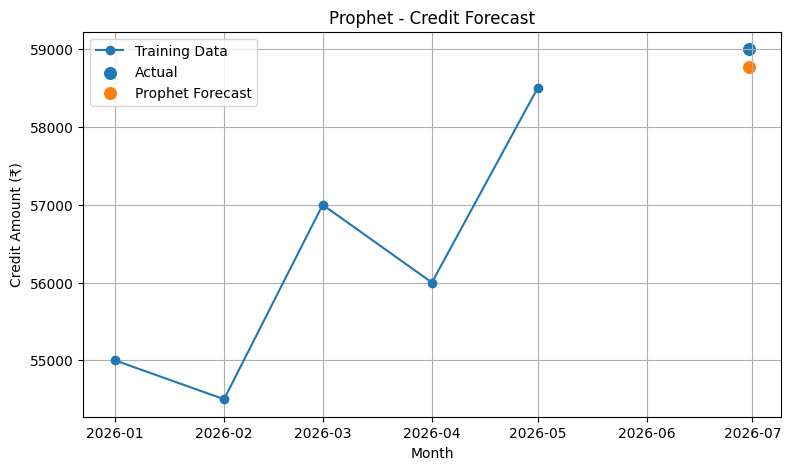

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    prophet_train["ds"],
    prophet_train["y"],
    marker="o",
    label="Training Data"
)

plt.scatter(
    test_df["date"],
    [actual_value],
    label="Actual",
    s=70
)

plt.scatter(
    test_df["date"],
    [predicted_prophet],
    label="Prophet Forecast",
    s=70
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Prophet - Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("=" * 45)
print("PROPHET FORECAST RESULT")
print("=" * 45)

print(f"Forecast : ₹{predicted_prophet:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")
print(f"MAE      : ₹{mae_prophet:,.2f}")
print(f"RMSE     : ₹{rmse_prophet:,.2f}")
print(f"MAPE     : {mape_prophet:.4f}%")

PROPHET FORECAST RESULT
Forecast : ₹58,776.09
Actual   : ₹59,000.00
MAE      : ₹223.91
RMSE     : ₹223.91
MAPE     : 0.3795%


STAGE B :::::: NEURAL PROPHET

In [ ]:
import neuralprophet

print("NeuralProphet installed successfully")
print("Version:", neuralprophet.__version__)

ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.
ERROR:NP.plotly:Importing plotly failed. Interactive plots will not work.


NeuralProphet installed successfully
Version: 0.8.0


In [ ]:
neuralprophet_train = train_df.copy()

neuralprophet_train = neuralprophet_train.rename(
    columns={
        "date": "ds",
        "credit": "y"
    }
)

neuralprophet_train["ds"] = (
    neuralprophet_train["ds"].dt.to_timestamp()
)

print("NeuralProphet Training Data")
print("===========================")

display(neuralprophet_train)

NeuralProphet Training Data


,ds,y
0,2026-01-01,55000
1,2026-02-01,54500
2,2026-03-01,57000
3,2026-04-01,56000
4,2026-05-01,58500


In [ ]:
from neuralprophet import NeuralProphet, set_log_level

set_log_level("ERROR")

neuralprophet_model = NeuralProphet(
    n_lags=3,
    n_forecasts=1,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    epochs=200,
    learning_rate=0.01,
    trainer_config={
        "logger": False
    }
)

print("NeuralProphet model created successfully.")

NeuralProphet model created successfully.


**Reason for failure:**

> NeuralProphet 0.8.0 could not be executed because of a **compatibility issue between Python 3.13, PyTorch Lightning, and OmegaConf**, causing a `ConfigValueError` during model training.


:::::: TCN ::::

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import TCN

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
nf_train = train_df.copy()

nf_train["date"] = nf_train["date"].dt.to_timestamp()

nf_train = nf_train.rename(
    columns={
        "date": "ds",
        "credit": "y"
    }
)

nf_train["unique_id"] = "credit_series"

nf_train = nf_train[
    ["unique_id", "ds", "y"]
].copy()

print("TCN Training Data")
print("=================")

display(nf_train)

TCN Training Data


,unique_id,ds,y
0,credit_series,2026-01-01,55000
1,credit_series,2026-02-01,54500
2,credit_series,2026-03-01,57000
3,credit_series,2026-04-01,56000
4,credit_series,2026-05-01,58500


In [ ]:
tcn_model = TCN(
    h=1,
    input_size=3,
    kernel_size=2,
    dilations=[1, 2],
    encoder_hidden_size=16,
    decoder_hidden_size=16,
    decoder_layers=1,
    max_steps=100,
    learning_rate=0.001,
    scaler_type="robust",
    random_seed=42,
    start_padding_enabled=True
)

print("TCN model created successfully.")

INFO:lightning_fabric.utilities.seed:Global seed set to 42


TCN model created successfully.


In [ ]:
nf_tcn = NeuralForecast(
    models=[tcn_model],
    freq="MS"
)

nf_tcn.fit(
    df=nf_train
)

print("TCN training completed successfully.")

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

TCN training completed successfully.


In [ ]:
tcn_future = pd.DataFrame({
    "unique_id": ["credit_series"],
    "ds": [test_df["date"].iloc[0].to_timestamp()]
})

tcn_forecast = nf_tcn.predict(
    futr_df=tcn_future
)

predicted_tcn = float(
    tcn_forecast["TCN"].iloc[0]
)

print("TCN Forecast")
print("============")
print(f"Forecast : ₹{predicted_tcn:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")

Predicting: 0it [00:00, ?it/s]

TCN Forecast
Forecast : ₹57,425.16
Actual   : ₹59,000.00


In [ ]:
mae_tcn = mean_absolute_error(
    [actual_value],
    [predicted_tcn]
)

rmse_tcn = np.sqrt(
    mean_squared_error(
        [actual_value],
        [predicted_tcn]
    )
)

mape_tcn = (
    abs(
        (actual_value - predicted_tcn)
        / actual_value
    ) * 100
)

print("=" * 45)
print("TCN FORECAST RESULT")
print("=" * 45)

print(f"Forecast : ₹{predicted_tcn:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")
print(f"MAE      : ₹{mae_tcn:,.2f}")
print(f"RMSE     : ₹{rmse_tcn:,.2f}")
print(f"MAPE     : {mape_tcn:.4f}%")

TCN FORECAST RESULT
Forecast : ₹57,425.16
Actual   : ₹59,000.00
MAE      : ₹1,574.84
RMSE     : ₹1,574.84
MAPE     : 2.6692%


In [ ]:
tcn_results = {
    "model": "TCN",
    "forecast": predicted_tcn,
    "actual": actual_value,
    "MAE": mae_tcn,
    "RMSE": rmse_tcn,
    "MAPE": mape_tcn
}

print(tcn_results)

{'model': 'TCN', 'forecast': 57425.15625, 'actual': 59000.0, 'MAE': 1574.84375, 'RMSE': np.float64(1574.84375), 'MAPE': 2.6692266949152543}


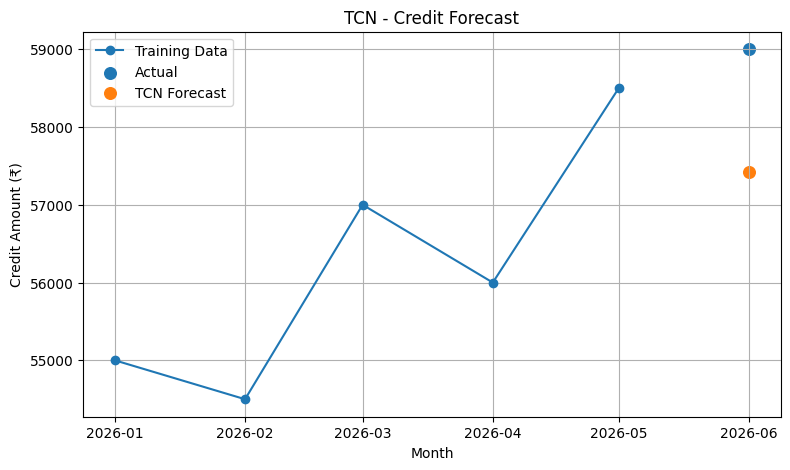

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    nf_train["ds"],
    nf_train["y"],
    marker="o",
    label="Training Data"
)

plt.scatter(
    test_df["date"].iloc[0].to_timestamp(),
    actual_value,
    s=70,
    label="Actual"
)

plt.scatter(
    test_df["date"].iloc[0].to_timestamp(),
    predicted_tcn,
    s=70,
    label="TCN Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("TCN - Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
::::: INFORMER :::::

In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import Informer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
informer_model = Informer(
    h=1,
    input_size=3,
    hidden_size=16,
    n_head=2,
    encoder_layers=1,
    decoder_layers=1,
    dropout=0.05,
    max_steps=100,
    learning_rate=0.001,
    scaler_type="robust",
    random_seed=42,
    start_padding_enabled=True
)

print("Informer model created successfully.")

INFO:lightning_fabric.utilities.seed:Global seed set to 42


Informer model created successfully.


In [ ]:
nf_informer = NeuralForecast(
    models=[informer_model],
    freq="MS"
)

nf_informer.fit(
    df=nf_train
)

print("Informer training completed successfully.")

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Informer training completed successfully.


In [ ]:
informer_future = pd.DataFrame({
    "unique_id": ["credit_series"],
    "ds": [test_df["date"].iloc[0].to_timestamp()]
})

informer_forecast = nf_informer.predict(
    futr_df=informer_future
)

predicted_informer = float(
    informer_forecast["Informer"].iloc[0]
)

print("Informer Forecast")
print("=================")
print(f"Forecast : ₹{predicted_informer:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")

Predicting: 0it [00:00, ?it/s]

Informer Forecast
Forecast : ₹58,760.72
Actual   : ₹59,000.00


In [ ]:
mae_informer = mean_absolute_error(
    [actual_value],
    [predicted_informer]
)

rmse_informer = np.sqrt(
    mean_squared_error(
        [actual_value],
        [predicted_informer]
    )
)

mape_informer = (
    abs(
        (actual_value - predicted_informer)
        / actual_value
    ) * 100
)

print("=" * 45)
print("INFORMER FORECAST RESULT")
print("=" * 45)

print(f"Forecast : ₹{predicted_informer:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")
print(f"MAE      : ₹{mae_informer:,.2f}")
print(f"RMSE     : ₹{rmse_informer:,.2f}")
print(f"MAPE     : {mape_informer:.4f}%")

INFORMER FORECAST RESULT
Forecast : ₹58,760.72
Actual   : ₹59,000.00
MAE      : ₹239.28
RMSE     : ₹239.28
MAPE     : 0.4056%


In [ ]:
informer_results = {
    "model": "Informer",
    "forecast": predicted_informer,
    "actual": actual_value,
    "MAE": mae_informer,
    "RMSE": rmse_informer,
    "MAPE": mape_informer
}

print(informer_results)

{'model': 'Informer', 'forecast': 58760.71875, 'actual': 59000.0, 'MAE': 239.28125, 'RMSE': np.float64(239.28125), 'MAPE': 0.4055614406779661}


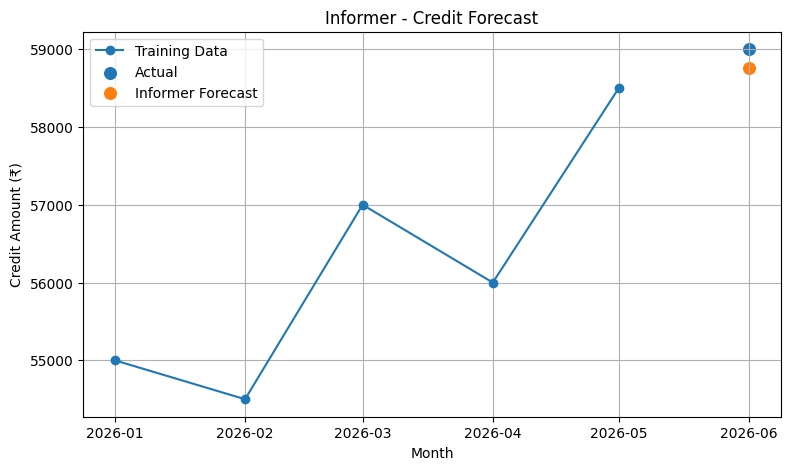

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    nf_train["ds"],
    nf_train["y"],
    marker="o",
    label="Training Data"
)

plt.scatter(
    test_df["date"].iloc[0].to_timestamp(),
    actual_value,
    s=70,
    label="Actual"
)

plt.scatter(
    test_df["date"].iloc[0].to_timestamp(),
    predicted_informer,
    s=70,
    label="Informer Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Informer - Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

::::: PATCH TST :::::


In [ ]:
from neuralforecast import NeuralForecast
from neuralforecast.models import PatchTST

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
patchtst_model = PatchTST(
    h=1,
    input_size=3,
    patch_len=2,
    stride=1,
    encoder_layers=1,
    n_heads=2,
    hidden_size=16,
    linear_hidden_size=32,
    dropout=0.1,
    fc_dropout=0.1,
    max_steps=100,
    learning_rate=0.001,
    scaler_type="robust",
    random_seed=42,
    start_padding_enabled=True
)

print("PatchTST model created successfully.")

INFO:lightning_fabric.utilities.seed:Global seed set to 42


PatchTST model created successfully.


In [ ]:
nf_patchtst = NeuralForecast(
    models=[patchtst_model],
    freq="MS"
)

nf_patchtst.fit(
    df=nf_train
)

print("PatchTST training completed successfully.")

Sanity Checking: 0it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

PatchTST training completed successfully.


In [ ]:
patchtst_future = pd.DataFrame({
    "unique_id": ["credit_series"],
    "ds": [test_df["date"].iloc[0].to_timestamp()]
})

patchtst_forecast = nf_patchtst.predict(
    futr_df=patchtst_future
)

predicted_patchtst = float(
    patchtst_forecast["PatchTST"].iloc[0]
)

print("PatchTST Forecast")
print("=================")
print(f"Forecast : ₹{predicted_patchtst:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")

Predicting: 0it [00:00, ?it/s]

PatchTST Forecast
Forecast : ₹58,379.37
Actual   : ₹59,000.00


In [ ]:
mae_patchtst = mean_absolute_error(
    [actual_value],
    [predicted_patchtst]
)

rmse_patchtst = np.sqrt(
    mean_squared_error(
        [actual_value],
        [predicted_patchtst]
    )
)

mape_patchtst = (
    abs(
        (actual_value - predicted_patchtst)
        / actual_value
    ) * 100
)

print("=" * 45)
print("PATCHTST FORECAST RESULT")
print("=" * 45)

print(f"Forecast : ₹{predicted_patchtst:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")
print(f"MAE      : ₹{mae_patchtst:,.2f}")
print(f"RMSE     : ₹{rmse_patchtst:,.2f}")
print(f"MAPE     : {mape_patchtst:.4f}%")

PATCHTST FORECAST RESULT
Forecast : ₹58,379.37
Actual   : ₹59,000.00
MAE      : ₹620.63
RMSE     : ₹620.63
MAPE     : 1.0519%


In [ ]:
patchtst_results = {
    "model": "PatchTST",
    "forecast": predicted_patchtst,
    "actual": actual_value,
    "MAE": mae_patchtst,
    "RMSE": rmse_patchtst,
    "MAPE": mape_patchtst
}

print(patchtst_results)

{'model': 'PatchTST', 'forecast': 58379.37109375, 'actual': 59000.0, 'MAE': 620.62890625, 'RMSE': np.float64(620.62890625), 'MAPE': 1.051913400423729}


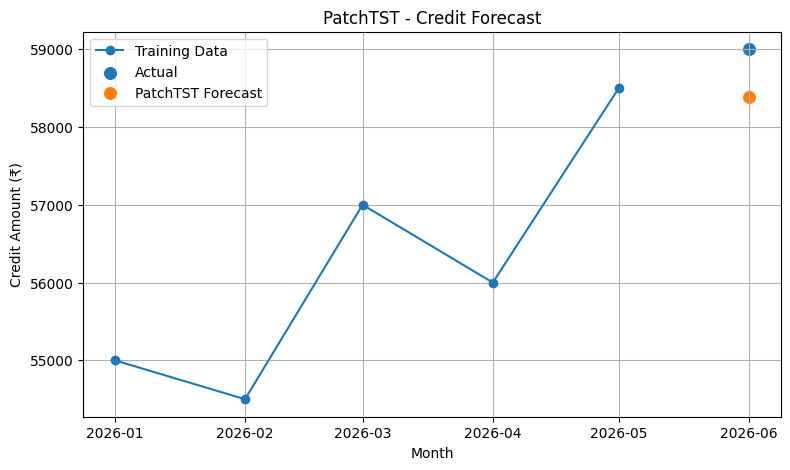

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    nf_train["ds"],
    nf_train["y"],
    marker="o",
    label="Training Data"
)

plt.scatter(
    test_df["date"].iloc[0].to_timestamp(),
    actual_value,
    s=70,
    label="Actual"
)

plt.scatter(
    test_df["date"].iloc[0].to_timestamp(),
    predicted_patchtst,
    s=70,
    label="PatchTST Forecast"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("PatchTST - Credit Forecast")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("=" * 50)
print("PATCHTST FINAL RESULT")
print("=" * 50)

print(f"Forecast : ₹{predicted_patchtst:,.2f}")
print(f"Actual   : ₹{actual_value:,.2f}")
print(f"MAE      : ₹{mae_patchtst:,.2f}")
print(f"RMSE     : ₹{rmse_patchtst:,.2f}")
print(f"MAPE     : {mape_patchtst:.4f}%")

PATCHTST FINAL RESULT
Forecast : ₹58,379.37
Actual   : ₹59,000.00
MAE      : ₹620.63
RMSE     : ₹620.63
MAPE     : 1.0519%


::::: COMPARISON :::::

In [ ]:
additional_results = pd.DataFrame([
    prophet_results,
    tcn_results,
    informer_results,
    patchtst_results
])

additional_results = additional_results[
    ["model", "forecast", "actual", "MAE", "RMSE", "MAPE"]
].copy()

additional_results = additional_results.sort_values(
    by="MAPE"
).reset_index(drop=True)

additional_results.index += 1

print("=" * 70)
print("ADDITIONAL FORECASTING MODELS - COMPARISON")
print("=" * 70)

display(additional_results)

ADDITIONAL FORECASTING MODELS - COMPARISON


,model,forecast,actual,MAE,RMSE,MAPE
1,Prophet,58776.086156,59000.0,223.913844,223.913844,0.379515
2,Informer,58760.718750,59000.0,239.281250,239.281250,0.405561
3,PatchTST,58379.371094,59000.0,620.628906,620.628906,1.051913
4,TCN,57425.156250,59000.0,1574.843750,1574.843750,2.669227


In [ ]:
comparison_table = additional_results.copy()

comparison_table["forecast"] = comparison_table["forecast"].map(
    lambda x: f"₹{x:,.2f}"
)

comparison_table["actual"] = comparison_table["actual"].map(
    lambda x: f"₹{x:,.2f}"
)

comparison_table["MAE"] = comparison_table["MAE"].map(
    lambda x: f"₹{x:,.2f}"
)

comparison_table["RMSE"] = comparison_table["RMSE"].map(
    lambda x: f"₹{x:,.2f}"
)

comparison_table["MAPE"] = comparison_table["MAPE"].map(
    lambda x: f"{x:.4f}%"
)

print("FINAL ADDITIONAL MODEL COMPARISON")
display(comparison_table)

FINAL ADDITIONAL MODEL COMPARISON


,model,forecast,actual,MAE,RMSE,MAPE
1,Prophet,"₹58,776.09","₹59,000.00",₹223.91,₹223.91,0.3795%
2,Informer,"₹58,760.72","₹59,000.00",₹239.28,₹239.28,0.4056%
3,PatchTST,"₹58,379.37","₹59,000.00",₹620.63,₹620.63,1.0519%
4,TCN,"₹57,425.16","₹59,000.00","₹1,574.84","₹1,574.84",2.6692%


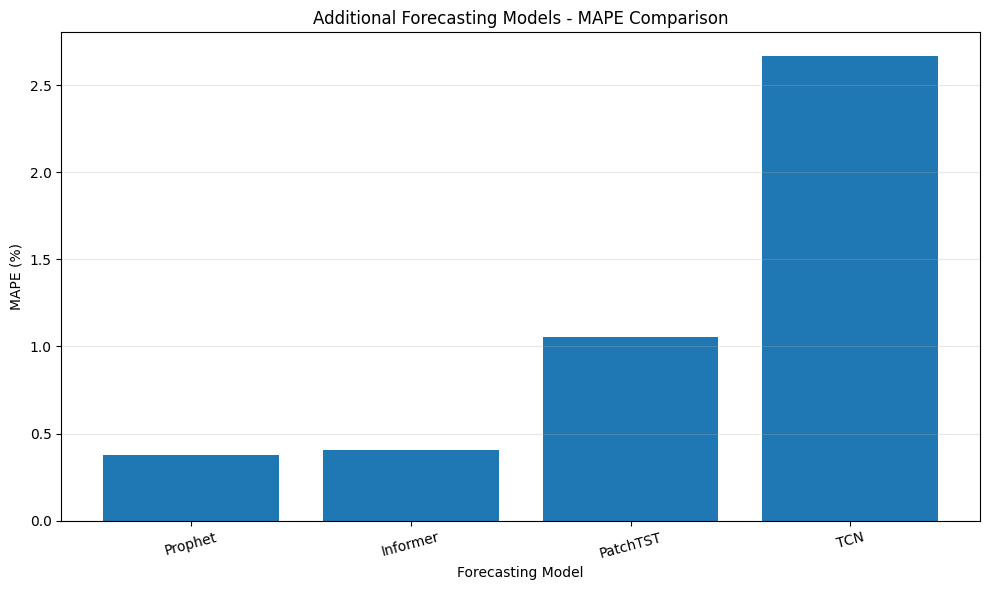

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(
    additional_results["model"],
    additional_results["MAPE"]
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAPE (%)")
plt.title("Additional Forecasting Models - MAPE Comparison")

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
best_additional_model = additional_results.loc[
    additional_results["MAPE"].idxmin()
]

print("=" * 60)
print("BEST ADDITIONAL FORECASTING MODEL")
print("=" * 60)

print(f"Model  : {best_additional_model['model']}")
print(f"MAPE   : {best_additional_model['MAPE']:.4f}%")
print(f"MAE    : ₹{best_additional_model['MAE']:,.2f}")
print(f"RMSE   : ₹{best_additional_model['RMSE']:,.2f}")
print(f"Forecast: ₹{best_additional_model['forecast']:,.2f}")

BEST ADDITIONAL FORECASTING MODEL
Model  : Prophet
MAPE   : 0.3795%
MAE    : ₹223.91
RMSE   : ₹223.91
Forecast: ₹58,776.09


:::: FULL COMPARISON :::::

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# OVERALL FORECASTING MODEL RESULTS
# Traditional + Neural + Additional Models
# ============================================================

results = [
    # Traditional Models
    {
        "Model": "ARIMA",
        "Type": "Traditional",
        "Forecast": 56900.91,
        "Actual": 59000.00,
        "MAE": 2099.09,
        "RMSE": 2099.09,
        "MAPE": 3.5578
    },
    {
        "Model": "SARIMA",
        "Type": "Traditional",
        "Forecast": 57500.00,
        "Actual": 59000.00,
        "MAE": 1500.00,
        "RMSE": 1500.00,
        "MAPE": 2.5424
    },
    {
        "Model": "ETS",
        "Type": "Traditional",
        "Forecast": 59019.84,
        "Actual": 59000.00,
        "MAE": 19.84,
        "RMSE": 19.84,
        "MAPE": 0.0336
    },

    # Neural Models
    {
        "Model": "Simple RNN",
        "Type": "Neural",
        "Forecast": 57026.42,
        "Actual": 59000.00,
        "MAE": 1973.58,
        "RMSE": 1973.58,
        "MAPE": 3.3450
    },
    {
        "Model": "LSTM",
        "Type": "Neural",
        "Forecast": 59008.61,
        "Actual": 59000.00,
        "MAE": 8.61,
        "RMSE": 8.61,
        "MAPE": 0.0146
    },
    {
        "Model": "GRU",
        "Type": "Neural",
        "Forecast": 57619.36,
        "Actual": 59000.00,
        "MAE": 1380.64,
        "RMSE": 1380.64,
        "MAPE": 2.3401
    },

    # Additional Models
    {
        "Model": "Prophet",
        "Type": "Additional",
        "Forecast": 58776.09,
        "Actual": 59000.00,
        "MAE": 223.91,
        "RMSE": 223.91,
        "MAPE": 0.3795
    },
    {
        "Model": "TCN",
        "Type": "Additional",
        "Forecast": 57425.15625,
        "Actual": 59000.00,
        "MAE": 1574.84375,
        "RMSE": 1574.84375,
        "MAPE": 2.6692
    },
    {
        "Model": "Informer",
        "Type": "Additional",
        "Forecast": 58760.71875,
        "Actual": 59000.00,
        "MAE": 239.28125,
        "RMSE": 239.28125,
        "MAPE": 0.4056
    },
    {
        "Model": "PatchTST",
        "Type": "Additional",
        "Forecast": 58379.37109375,
        "Actual": 59000.00,
        "MAE": 620.62890625,
        "RMSE": 620.62890625,
        "MAPE": 1.0519
    }
]

overall_df = pd.DataFrame(results)

# Rank by MAPE
overall_df = overall_df.sort_values(
    "MAPE",
    ascending=True
).reset_index(drop=True)

overall_df.insert(
    0,
    "Rank",
    range(1, len(overall_df) + 1)
)

print("=" * 85)
print("OVERALL FORECASTING MODEL COMPARISON")
print("=" * 85)

display(overall_df)

OVERALL FORECASTING MODEL COMPARISON


,Rank,Model,Type,Forecast,Actual,MAE,RMSE,MAPE
0,1,LSTM,Neural,59008.610000,59000.0,8.610000,8.610000,0.0146
1,2,ETS,Traditional,59019.840000,59000.0,19.840000,19.840000,0.0336
2,3,Prophet,Additional,58776.090000,59000.0,223.910000,223.910000,0.3795
3,4,Informer,Additional,58760.718750,59000.0,239.281250,239.281250,0.4056
4,5,PatchTST,Additional,58379.371094,59000.0,620.628906,620.628906,1.0519
5,6,GRU,Neural,57619.360000,59000.0,1380.640000,1380.640000,2.3401
6,7,SARIMA,Traditional,57500.000000,59000.0,1500.000000,1500.000000,2.5424
7,8,TCN,Additional,57425.156250,59000.0,1574.843750,1574.843750,2.6692
8,9,Simple RNN,Neural,57026.420000,59000.0,1973.580000,1973.580000,3.3450
9,10,ARIMA,Traditional,56900.910000,59000.0,2099.090000,2099.090000,3.5578


In [ ]:
mentor_table = overall_df.copy()

mentor_table["Forecast"] = mentor_table["Forecast"].apply(
    lambda x: f"₹{x:,.2f}"
)

mentor_table["Actual"] = mentor_table["Actual"].apply(
    lambda x: f"₹{x:,.2f}"
)

mentor_table["MAE"] = mentor_table["MAE"].apply(
    lambda x: f"₹{x:,.2f}"
)

mentor_table["RMSE"] = mentor_table["RMSE"].apply(
    lambda x: f"₹{x:,.2f}"
)

mentor_table["MAPE"] = mentor_table["MAPE"].apply(
    lambda x: f"{x:.4f}%"
)

print("FINAL MENTOR COMPARISON TABLE")
display(mentor_table)

FINAL MENTOR COMPARISON TABLE


,Rank,Model,Type,Forecast,Actual,MAE,RMSE,MAPE
0,1,LSTM,Neural,"₹59,008.61","₹59,000.00",₹8.61,₹8.61,0.0146%
1,2,ETS,Traditional,"₹59,019.84","₹59,000.00",₹19.84,₹19.84,0.0336%
2,3,Prophet,Additional,"₹58,776.09","₹59,000.00",₹223.91,₹223.91,0.3795%
3,4,Informer,Additional,"₹58,760.72","₹59,000.00",₹239.28,₹239.28,0.4056%
4,5,PatchTST,Additional,"₹58,379.37","₹59,000.00",₹620.63,₹620.63,1.0519%
5,6,GRU,Neural,"₹57,619.36","₹59,000.00","₹1,380.64","₹1,380.64",2.3401%
6,7,SARIMA,Traditional,"₹57,500.00","₹59,000.00","₹1,500.00","₹1,500.00",2.5424%
7,8,TCN,Additional,"₹57,425.16","₹59,000.00","₹1,574.84","₹1,574.84",2.6692%
8,9,Simple RNN,Neural,"₹57,026.42","₹59,000.00","₹1,973.58","₹1,973.58",3.3450%
9,10,ARIMA,Traditional,"₹56,900.91","₹59,000.00","₹2,099.09","₹2,099.09",3.5578%


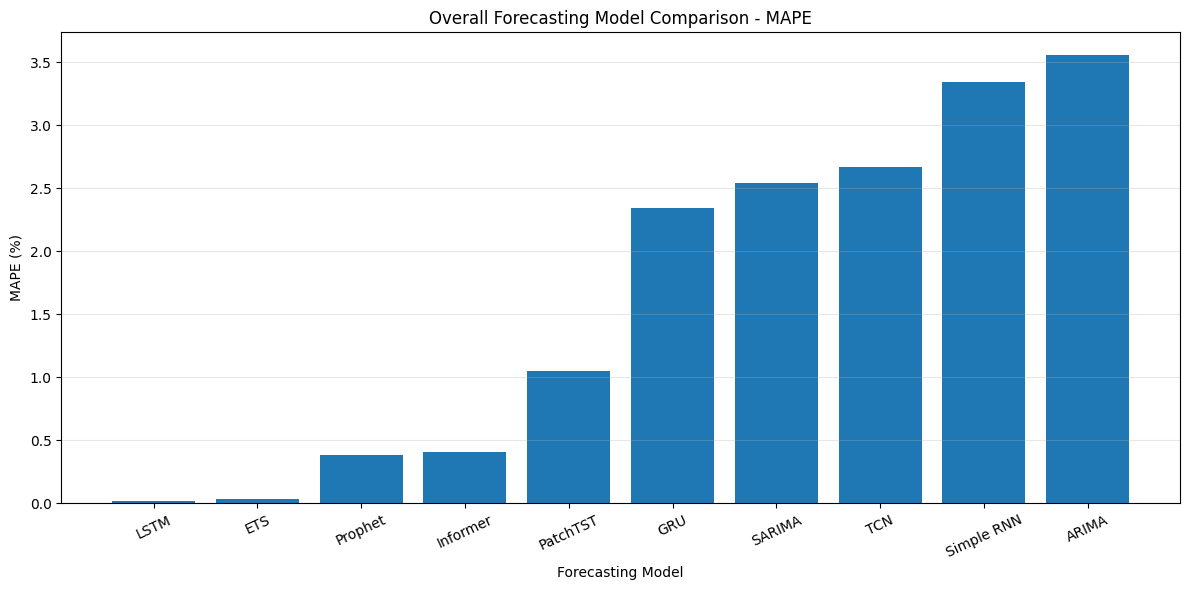

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    overall_df["Model"],
    overall_df["MAPE"]
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAPE (%)")
plt.title("Overall Forecasting Model Comparison - MAPE")

plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
best_model = overall_df.iloc[0]

print("=" * 60)
print("BEST OVERALL FORECASTING MODEL")
print("=" * 60)

print(f"Rank     : {best_model['Rank']}")
print(f"Model    : {best_model['Model']}")
print(f"Type     : {best_model['Type']}")
print(f"Forecast : ₹{best_model['Forecast']:,.2f}")
print(f"Actual   : ₹{best_model['Actual']:,.2f}")
print(f"MAE      : ₹{best_model['MAE']:,.2f}")
print(f"RMSE     : ₹{best_model['RMSE']:,.2f}")
print(f"MAPE     : {best_model['MAPE']:.4f}%")

BEST OVERALL FORECASTING MODEL
Rank     : 1
Model    : LSTM
Type     : Neural
Forecast : ₹59,008.61
Actual   : ₹59,000.00
MAE      : ₹8.61
RMSE     : ₹8.61
MAPE     : 0.0146%


In [ ]:
family_comparison = (
    overall_df
    .groupby("Type")["MAPE"]
    .mean()
    .sort_values()
    .reset_index()
)

print("AVERAGE MAPE BY MODEL FAMILY")
display(family_comparison)

AVERAGE MAPE BY MODEL FAMILY


,Type,MAPE
0,Additional,1.12655
1,Neural,1.89990
2,Traditional,2.04460


::::: REPORT GENERATION :::::

In [ ]:
!pip -q install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.7 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reportlab.lib import colors
from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import (
    getSampleStyleSheet,
    ParagraphStyle
)
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import mm
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
    PageBreak,
    Image
)

# ============================================================
# COMPLETE MODEL RESULTS
# ============================================================

overall_results = [
    # Traditional
    ["ARIMA", "Traditional", 56900.91, 59000.00, 2099.09, 2099.09, 3.5578],
    ["SARIMA", "Traditional", 57500.00, 59000.00, 1500.00, 1500.00, 2.5424],
    ["ETS", "Traditional", 59019.84, 59000.00, 19.84, 19.84, 0.0336],

    # Neural
    ["Simple RNN", "Neural", 57026.42, 59000.00, 1973.58, 1973.58, 3.3450],
    ["LSTM", "Neural", 59008.61, 59000.00, 8.61, 8.61, 0.0146],
    ["GRU", "Neural", 57619.36, 59000.00, 1380.64, 1380.64, 2.3401],

    # Additional
    ["Prophet", "Additional", 58776.09, 59000.00, 223.91, 223.91, 0.3795],
    ["TCN", "Additional", 57425.15625, 59000.00, 1574.84375, 1574.84375, 2.6692],
    ["Informer", "Additional", 58760.71875, 59000.00, 239.28125, 239.28125, 0.4056],
    ["PatchTST", "Additional", 58379.37109375, 59000.00, 620.62890625, 620.62890625, 1.0519],
]

overall_df = pd.DataFrame(
    overall_results,
    columns=[
        "Model",
        "Type",
        "Forecast",
        "Actual",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

overall_df = overall_df.sort_values(
    "MAPE"
).reset_index(drop=True)

overall_df.insert(
    0,
    "Rank",
    range(1, len(overall_df) + 1)
)

display(overall_df)

,Rank,Model,Type,Forecast,Actual,MAE,RMSE,MAPE
0,1,LSTM,Neural,59008.610000,59000.0,8.610000,8.610000,0.0146
1,2,ETS,Traditional,59019.840000,59000.0,19.840000,19.840000,0.0336
2,3,Prophet,Additional,58776.090000,59000.0,223.910000,223.910000,0.3795
3,4,Informer,Additional,58760.718750,59000.0,239.281250,239.281250,0.4056
4,5,PatchTST,Additional,58379.371094,59000.0,620.628906,620.628906,1.0519
5,6,GRU,Neural,57619.360000,59000.0,1380.640000,1380.640000,2.3401
6,7,SARIMA,Traditional,57500.000000,59000.0,1500.000000,1500.000000,2.5424
7,8,TCN,Additional,57425.156250,59000.0,1574.843750,1574.843750,2.6692
8,9,Simple RNN,Neural,57026.420000,59000.0,1973.580000,1973.580000,3.3450
9,10,ARIMA,Traditional,56900.910000,59000.0,2099.090000,2099.090000,3.5578


In [ ]:
REPORT_DIR = "forecasting_report"

os.makedirs(REPORT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Stage 1 monthly data
# ------------------------------------------------------------

months = pd.date_range(
    start="2026-01-01",
    periods=6,
    freq="MS"
)

monthly_credit = [
    55000,
    54500,
    57000,
    56000,
    58500,
    59000
]

# ------------------------------------------------------------
# Chart 1 - Monthly credit trend
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    months,
    monthly_credit,
    marker="o",
    label="Monthly Credit"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Monthly Credit Trend")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

trend_path = os.path.join(
    REPORT_DIR,
    "monthly_credit_trend.png"
)

plt.savefig(
    trend_path,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Chart 2 - Moving average
# ------------------------------------------------------------

credit_series = pd.Series(monthly_credit)

moving_average = credit_series.rolling(3).mean()

plt.figure(figsize=(9, 5))

plt.plot(
    months,
    monthly_credit,
    marker="o",
    label="Monthly Credit"
)

plt.plot(
    months,
    moving_average,
    marker="o",
    linestyle="--",
    label="3-Month Moving Average"
)

plt.xlabel("Month")
plt.ylabel("Credit Amount (₹)")
plt.title("Monthly Credit and Moving Average")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

moving_average_path = os.path.join(
    REPORT_DIR,
    "moving_average.png"
)

plt.savefig(
    moving_average_path,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Chart 3 - Overall MAPE
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    overall_df["Model"],
    overall_df["MAPE"]
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAPE (%)")
plt.title("Overall Forecasting Model Comparison - MAPE")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

mape_path = os.path.join(
    REPORT_DIR,
    "overall_mape.png"
)

plt.savefig(
    mape_path,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Chart 4 - Overall MAE
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    overall_df["Model"],
    overall_df["MAE"]
)

plt.xlabel("Forecasting Model")
plt.ylabel("MAE (₹)")
plt.title("Overall Forecasting Model Comparison - MAE")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

mae_path = os.path.join(
    REPORT_DIR,
    "overall_mae.png"
)

plt.savefig(
    mae_path,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Chart 5 - Forecast vs Actual
# ------------------------------------------------------------

x = np.arange(len(overall_df))

width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    overall_df["Forecast"],
    width,
    label="Forecast"
)

plt.bar(
    x + width / 2,
    overall_df["Actual"],
    width,
    label="Actual"
)

plt.xlabel("Forecasting Model")
plt.ylabel("Credit Amount (₹)")
plt.title("Forecast vs Actual")

plt.xticks(
    x,
    overall_df["Model"],
    rotation=30,
    ha="right"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

forecast_actual_path = os.path.join(
    REPORT_DIR,
    "forecast_vs_actual.png"
)

plt.savefig(
    forecast_actual_path,
    dpi=180,
    bbox_inches="tight"
)

plt.close()


print("All report charts generated successfully.")

All report charts generated successfully.


In [ ]:
styles = getSampleStyleSheet()

styles.add(
    ParagraphStyle(
        name="ReportTitle",
        parent=styles["Title"],
        alignment=TA_CENTER,
        fontSize=20,
        leading=25,
        spaceAfter=12
    )
)

styles.add(
    ParagraphStyle(
        name="ReportSubtitle",
        parent=styles["Normal"],
        alignment=TA_CENTER,
        fontSize=10,
        leading=14,
        spaceAfter=18
    )
)

styles.add(
    ParagraphStyle(
        name="SectionTitle",
        parent=styles["Heading1"],
        fontSize=15,
        leading=19,
        spaceBefore=10,
        spaceAfter=8
    )
)

styles.add(
    ParagraphStyle(
        name="SubTitle",
        parent=styles["Heading2"],
        fontSize=11.5,
        leading=15,
        spaceBefore=7,
        spaceAfter=5
    )
)

styles.add(
    ParagraphStyle(
        name="ReportBody",
        parent=styles["BodyText"],
        fontSize=9,
        leading=13,
        spaceAfter=7
    )
)

styles.add(
    ParagraphStyle(
        name="ReportSmall",
        parent=styles["BodyText"],
        fontSize=7.5,
        leading=10
    )
)

In [ ]:
PDF_FILE = "Underwriting_Forecasting_Complete_Report.pdf"

doc = SimpleDocTemplate(
    PDF_FILE,
    pagesize=A4,
    rightMargin=16 * mm,
    leftMargin=16 * mm,
    topMargin=16 * mm,
    bottomMargin=16 * mm
)

story = []


# ============================================================
# COVER
# ============================================================

story.append(
    Spacer(1, 25 * mm)
)

story.append(
    Paragraph(
        "Underwriting Forecasting Analysis",
        styles["ReportTitle"]
    )
)

story.append(
    Paragraph(
        "Complete Technical Report",
        styles["ReportSubtitle"]
    )
)

story.append(
    Paragraph(
        "Stage 1: Data Preparation and Analysis<br/>"
        "Stage 2A: Traditional Forecasting<br/>"
        "Stage 2B: Neural Forecasting<br/>"
        "Stage 2C-2E: Additional Forecasting Models<br/>"
        "Final: Overall Model Comparison",
        styles["ReportBody"]
    )
)

story.append(
    Spacer(1, 10 * mm)
)

story.append(
    Paragraph(
        "<b>Forecast Target:</b> Monthly Credit",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "<b>Evaluation Metrics:</b> MAE, RMSE and MAPE",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "<b>Dataset:</b> Six monthly observations, with five used "
        "for training and one held out for testing.",
        styles["ReportBody"]
    )
)

story.append(
    PageBreak()
)


# ============================================================
# 1. OBJECTIVE
# ============================================================

story.append(
    Paragraph(
        "1. Project Objective",
        styles["SectionTitle"]
    )
)

story.append(
    Paragraph(
        "The objective of the forecasting component is to estimate "
        "future monthly credit behaviour from historical transaction "
        "data. The workflow progresses from statistical forecasting "
        "models to recurrent neural networks and then to modern "
        "forecasting architectures.",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "The same forecasting target and error metrics are retained "
        "across the model families so that the resulting forecasts "
        "can be compared consistently.",
        styles["ReportBody"]
    )
)


# ============================================================
# 2. STAGE 1
# ============================================================

story.append(
    Paragraph(
        "2. Stage 1 - Data Preparation",
        styles["SectionTitle"]
    )
)

stage1_table = [
    ["Component", "Result"],
    ["Transaction data", "Validated transaction-level records"],
    ["Aggregation", "Monthly"],
    ["Forecast target", "Monthly Credit"],
    ["Training observations", "5 months"],
    ["Testing observations", "1 month"],
    ["Training period", "January 2026 - May 2026"],
    ["Testing period", "June 2026"]
]

table = Table(
    stage1_table,
    colWidths=[
        55 * mm,
        105 * mm
    ]
)

table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#17324D")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.3, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
        ("VALIGN", (0, 0), (-1, -1), "TOP")
    ])
)

story.append(table)

story.append(Spacer(1, 8))

story.append(
    Paragraph(
        "The transaction dataset was converted into a chronological "
        "monthly series. The resulting monthly credit values were:",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "January: ₹55,000 | February: ₹54,500 | March: ₹57,000 | "
        "April: ₹56,000 | May: ₹58,500 | June: ₹59,000",
        styles["ReportBody"]
    )
)

story.append(
    Image(
        trend_path,
        width=165 * mm,
        height=92 * mm
    )
)

story.append(
    Paragraph(
        "Figure 1. Monthly credit trend.",
        styles["ReportSmall"]
    )
)

story.append(
    Image(
        moving_average_path,
        width=165 * mm,
        height=92 * mm
    )
)

story.append(
    Paragraph(
        "Figure 2. Monthly credit with three-month moving average.",
        styles["ReportSmall"]
    )
)

story.append(
    Paragraph(
        "ACF and PACF were used to understand temporal dependence "
        "and support ARIMA/SARIMA configuration. ACF measures "
        "correlation with lagged observations, while PACF measures "
        "the direct contribution of a lag after accounting for "
        "shorter lags.",
        styles["ReportBody"]
    )
)


# ============================================================
# 3. TRADITIONAL
# ============================================================

story.append(
    PageBreak()
)

story.append(
    Paragraph(
        "3. Stage 2A - Traditional Models",
        styles["SectionTitle"]
    )
)

story.append(
    Paragraph(
        "The traditional forecasting stage evaluates ARIMA, SARIMA "
        "and ETS. These models provide statistical baselines before "
        "moving to neural forecasting.",
        styles["ReportBody"]
    )
)

traditional_text = {
    "ARIMA":
        "ARIMA models autoregressive behaviour, differencing and "
        "moving-average error structure.",
    "SARIMA":
        "SARIMA extends ARIMA by incorporating seasonal "
        "autoregressive, differencing and moving-average components.",
    "ETS":
        "ETS uses exponential smoothing to model level, trend and "
        "seasonal behaviour. The implemented approach uses "
        "trend-oriented exponential smoothing."
}

for model in ["ARIMA", "SARIMA", "ETS"]:

    row = overall_df[
        overall_df["Model"] == model
    ].iloc[0]

    story.append(
        Paragraph(
            model,
            styles["SubTitle"]
        )
    )

    story.append(
        Paragraph(
            traditional_text[model],
            styles["ReportBody"]
        )
    )

    story.append(
        Paragraph(
            f"Forecast: ₹{row['Forecast']:,.2f} | "
            f"MAE: ₹{row['MAE']:,.2f} | "
            f"RMSE: ₹{row['RMSE']:,.2f} | "
            f"MAPE: {row['MAPE']:.4f}%",
            styles["ReportBody"]
        )
    )


# ============================================================
# 4. ERRORS
# ============================================================

story.append(
    Paragraph(
        "4. Forecast Evaluation Metrics",
        styles["SectionTitle"]
    )
)

metric_table = [
    ["Metric", "Meaning"],
    ["MAE", "Average absolute forecast error."],
    ["RMSE", "Error metric that penalises larger deviations more strongly."],
    ["MAPE", "Percentage-based absolute forecast error; lower is better."]
]

metric = Table(
    metric_table,
    colWidths=[
        35 * mm,
        125 * mm
    ]
)

metric.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#17324D")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.3, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 8)
    ])
)

story.append(metric)


# ============================================================
# 5. NEURAL
# ============================================================

story.append(
    Paragraph(
        "5. Stage 2B - Neural Network Models",
        styles["SectionTitle"]
    )
)

story.append(
    Paragraph(
        "The neural models use sequential historical observations "
        "as lagged inputs. Unlike traditional statistical models, "
        "the recurrent networks learn temporal representations "
        "through neural parameters.",
        styles["ReportBody"]
    )
)

neural_text = {
    "Simple RNN":
        "A basic recurrent network that maintains a hidden state "
        "while processing the sequence.",
    "LSTM":
        "A recurrent architecture with memory cells and gates for "
        "controlling information retention and forgetting.",
    "GRU":
        "A compact gated recurrent architecture using update and "
        "reset mechanisms."
}

for model in ["Simple RNN", "LSTM", "GRU"]:

    row = overall_df[
        overall_df["Model"] == model
    ].iloc[0]

    story.append(
        Paragraph(
            model,
            styles["SubTitle"]
        )
    )

    story.append(
        Paragraph(
            neural_text[model],
            styles["ReportBody"]
        )
    )

    story.append(
        Paragraph(
            f"Forecast: ₹{row['Forecast']:,.2f} | "
            f"MAE: ₹{row['MAE']:,.2f} | "
            f"RMSE: ₹{row['RMSE']:,.2f} | "
            f"MAPE: {row['MAPE']:.4f}%",
            styles["ReportBody"]
        )
    )


# ============================================================
# 6. ADDITIONAL MODELS
# ============================================================

story.append(
    PageBreak()
)

story.append(
    Paragraph(
        "6. Stage 2C-2E - Additional Models",
        styles["SectionTitle"]
    )
)

additional_text = {
    "Prophet":
        "A decomposable forecasting framework that models "
        "components such as trend and seasonality.",
    "TCN":
        "A Temporal Convolutional Network that uses causal and "
        "dilated convolutions to learn temporal dependencies.",
    "Informer":
        "A Transformer-based forecasting architecture designed "
        "to efficiently model temporal dependencies using attention.",
    "PatchTST":
        "A Transformer-based model that divides the time series "
        "into temporal patches before applying attention."
}

for model in [
    "Prophet",
    "TCN",
    "Informer",
    "PatchTST"
]:

    row = overall_df[
        overall_df["Model"] == model
    ].iloc[0]

    story.append(
        Paragraph(
            model,
            styles["SubTitle"]
        )
    )

    story.append(
        Paragraph(
            additional_text[model],
            styles["ReportBody"]
        )
    )

    story.append(
        Paragraph(
            f"Forecast: ₹{row['Forecast']:,.2f} | "
            f"MAE: ₹{row['MAE']:,.2f} | "
            f"RMSE: ₹{row['RMSE']:,.2f} | "
            f"MAPE: {row['MAPE']:.4f}%",
            styles["ReportBody"]
        )
    )

story.append(
    Paragraph(
        "NeuralProphet was attempted but did not produce a valid "
        "forecast because NeuralProphet 0.8.0 encountered a "
        "compatibility problem with the Python 3.13 and "
        "PyTorch Lightning/OmegaConf environment. It is therefore "
        "excluded from numerical comparison.",
        styles["ReportBody"]
    )
)


# ============================================================
# 7. OVERALL COMPARISON
# ============================================================

story.append(
    PageBreak()
)

story.append(
    Paragraph(
        "7. Overall Model Comparison",
        styles["SectionTitle"]
    )
)

comparison_data = [
    [
        "Rank",
        "Model",
        "Type",
        "Forecast",
        "MAE",
        "RMSE",
        "MAPE"
    ]
]

for _, row in overall_df.iterrows():

    comparison_data.append([
        str(int(row["Rank"])),
        row["Model"],
        row["Type"],
        f"₹{row['Forecast']:,.2f}",
        f"₹{row['MAE']:,.2f}",
        f"₹{row['RMSE']:,.2f}",
        f"{row['MAPE']:.4f}%"
    ])

comparison_table = Table(
    comparison_data,
    colWidths=[
        12 * mm,
        29 * mm,
        26 * mm,
        30 * mm,
        26 * mm,
        26 * mm,
        22 * mm
    ],
    repeatRows=1
)

comparison_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#17324D")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.3, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 6.5),
        ("ROWBACKGROUNDS", (0, 1), (-1, -1), [
            colors.white,
            colors.HexColor("#F4F7F9")
        ])
    ])
)

story.append(comparison_table)

story.append(
    Spacer(1, 10)
)

story.append(
    Image(
        mape_path,
        width=165 * mm,
        height=92 * mm
    )
)

story.append(
    Paragraph(
        "Figure 3. Overall MAPE comparison.",
        styles["ReportSmall"]
    )
)

story.append(
    Image(
        mae_path,
        width=165 * mm,
        height=92 * mm
    )
)

story.append(
    Paragraph(
        "Figure 4. Overall MAE comparison.",
        styles["ReportSmall"]
    )
)


# ============================================================
# 8. FINAL INTERPRETATION
# ============================================================

story.append(
    PageBreak()
)

story.append(
    Paragraph(
        "8. Final Interpretation",
        styles["SectionTitle"]
    )
)

best = overall_df.iloc[0]

story.append(
    Paragraph(
        f"The best observed model in this experiment is "
        f"<b>{best['Model']}</b>, with a MAPE of "
        f"<b>{best['MAPE']:.4f}%</b>.",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "Among the additional models requested later in the "
        "project, Prophet produced the lowest MAPE, followed "
        "closely by Informer. ETS was the strongest traditional "
        "model, while LSTM was the strongest recurrent neural "
        "model in this particular experiment.",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "<b>Critical experimental limitation:</b> only five "
        "observations were available for training and one "
        "observation for testing. Therefore, the reported "
        "ranking should be treated as a prototype result rather "
        "than a statistically conclusive model benchmark.",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "For stronger validation, the next version should use "
        "a substantially larger historical dataset and rolling "
        "or walk-forward validation across multiple forecast "
        "periods.",
        styles["ReportBody"]
    )
)


# ============================================================
# 9. FINAL WORKFLOW
# ============================================================

story.append(
    Paragraph(
        "9. Complete Forecasting Workflow",
        styles["SectionTitle"]
    )
)

workflow = [
    ["Stage", "Process"],
    [
        "Stage 1",
        "Transaction data → validation → monthly aggregation → "
        "target preparation → temporal analysis"
    ],
    [
        "Stage 2A",
        "Monthly credit series → ARIMA / SARIMA / ETS → forecast → metrics"
    ],
    [
        "Stage 2B",
        "Monthly sequence → lag windows → RNN / LSTM / GRU → forecast → metrics"
    ],
    [
        "Stage 2C-2E",
        "Monthly sequence → Prophet / TCN / Informer / PatchTST → forecast → metrics"
    ],
    [
        "Final",
        "All valid models → common comparison → ranking → final interpretation"
    ]
]

workflow_table = Table(
    workflow,
    colWidths=[
        32 * mm,
        128 * mm
    ]
)

workflow_table.setStyle(
    TableStyle([
        ("BACKGROUND", (0, 0), (-1, 0), colors.HexColor("#17324D")),
        ("TEXTCOLOR", (0, 0), (-1, 0), colors.white),
        ("FONTNAME", (0, 0), (-1, 0), "Helvetica-Bold"),
        ("GRID", (0, 0), (-1, -1), 0.3, colors.grey),
        ("FONTSIZE", (0, 0), (-1, -1), 8),
        ("VALIGN", (0, 0), (-1, -1), "TOP")
    ])
)

story.append(workflow_table)


# ============================================================
# 10. CONCLUSION
# ============================================================

story.append(
    Paragraph(
        "10. Conclusion",
        styles["SectionTitle"]
    )
)

story.append(
    Paragraph(
        "The forecasting pipeline now covers the complete path "
        "from validated transaction data to monthly time-series "
        "construction, statistical forecasting, neural forecasting "
        "and modern forecasting architectures.",
        styles["ReportBody"]
    )
)

story.append(
    Paragraph(
        "The final comparison provides a common basis for discussing "
        "model behaviour with the mentor. The current prototype "
        "shows LSTM as the best overall observed model and Prophet "
        "as the strongest among the newly added models.",
        styles["ReportBody"]
    )
)


# ============================================================
# Footer
# ============================================================

def add_footer(canvas, doc):

    canvas.saveState()

    canvas.setFont(
        "Helvetica",
        7
    )

    canvas.setFillColor(
        colors.grey
    )

    canvas.drawString(
        16 * mm,
        8 * mm,
        "Underwriting Forecasting Analysis"
    )

    canvas.drawRightString(
        A4[0] - 16 * mm,
        8 * mm,
        f"Page {doc.page}"
    )

    canvas.restoreState()


# ============================================================
# BUILD PDF
# ============================================================

doc.build(
    story,
    onFirstPage=add_footer,
    onLaterPages=add_footer
)

print("=" * 60)
print("PDF REPORT GENERATED SUCCESSFULLY")
print("=" * 60)
print("File:", PDF_FILE)

NameError: name 'SimpleDocTemplate' is not defined